In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

$C = S_0N(d_1)-Ke^{-rT}N(d_2)$

In [68]:
K = 100 #strike price
r = 0.05 #risk free interest rate
T = 1 #time to maturity; years
sigma = 0.2 #volatility

In [69]:
def call_price(S_0, K, r, sigma, T):

    d_1 = (np.log(S_0/K) + (r + sigma**2/2)*T)/(sigma*np.sqrt(T))
    d_2 = d_1 - sigma*np.sqrt(T)

    return S_0*norm.cdf(d_1) - K*np.exp(-r*T)*norm.cdf(d_2)

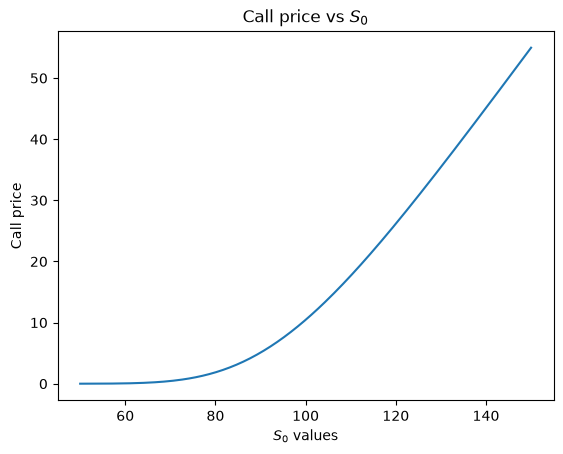

In [70]:
S_0 = np.linspace(50, 150, 200) #current stock price
C0 = []

for S in S_0:
    C = call_price(S, K, r, sigma, T)
    C0.append(C)

plt.plot(S_0, C0)
plt.xlabel('$S_0$ values')
plt.ylabel('Call price')
plt.title('Call price vs $S_0$')
plt.show()

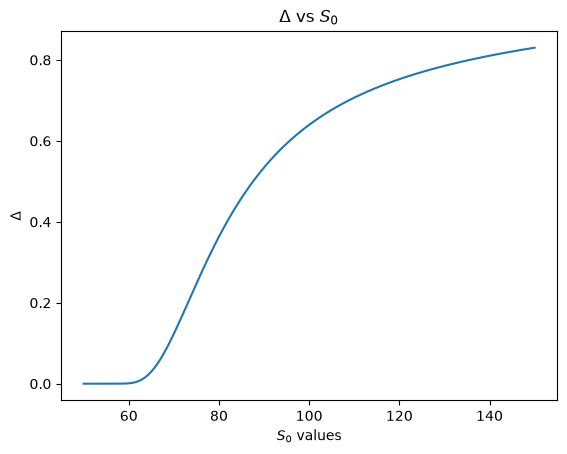

In [71]:
delta = Nd1
plt.plot(S_0values, delta)
plt.xlabel('$S_0$ values')
plt.ylabel('\u0394')
plt.title('\u0394 vs $S_0$')
plt.show()

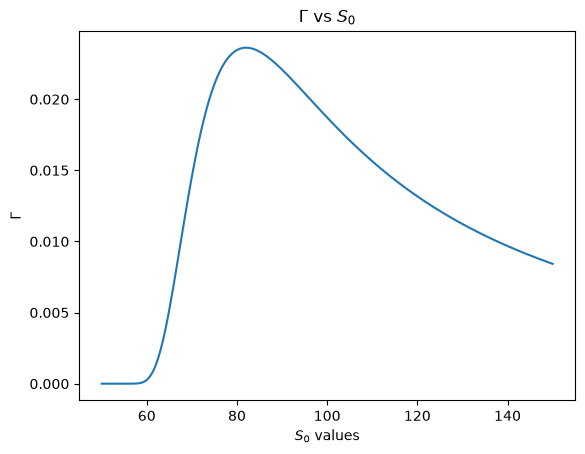

In [72]:
phid1 = norm.pdf(d_1)
gamma = phid1/(S_0 * sigma * np.sqrt(T))
plt.plot(S_0values, gamma)
plt.xlabel('$S_0$ values')
plt.ylabel('\u0393')
plt.title('\u0393 vs $S_0$')
plt.show()

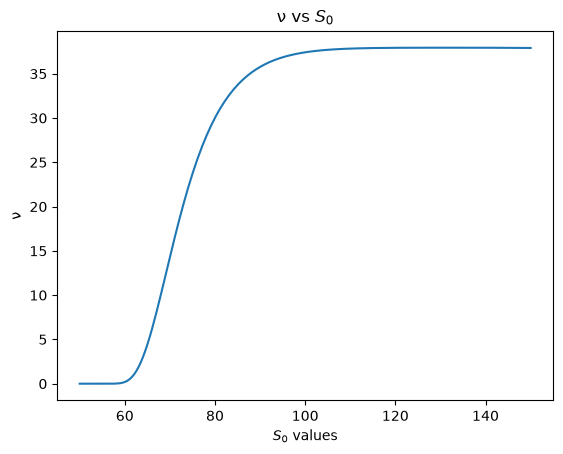

In [73]:
sigma_values = np.linspace(0.05, 1.0, 200)
d_11 = (np.log(S_0/K) + (r + ((sigma_values)**2/2))*T)/(sigma_values * np.sqrt(T))
phid11 = norm.pdf(d_11)
vega = S_0 * np.sqrt(T) * phid11
plt.plot(S_0values, vega)
plt.xlabel('$S_0$ values')
plt.ylabel('\u03BD')
plt.title('\u03BD vs $S_0$')
plt.show()

$P = Ke^{-rT}N(-d_2)-S_0N(-d_1)$

In [74]:
def put_price(S_0, K, r, sigma, T):

    d_1 = (np.log(S_0/K) + (r + sigma**2/2)*T)/(sigma*np.sqrt(T))
    d_2 = d_1 - sigma*np.sqrt(T)

    return K*np.exp(-r*T)*norm.cdf(-d_2) - S_0*norm.cdf(-d_1)

$C - P = S_0 - Ke^{-rT}$

In [75]:
def put_call_parity_check(S_0, K, r, sigma, T):
    lhs = call_price(S_0, K, r, sigma, T) - put_price(S_0, K, r, sigma, T)
    rhs = S_0 - K * (np.exp(-r*T))
    return np.isclose(lhs, rhs)